In [1]:
# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys, walk_through_dir

### 101 Food Classes: working with less data

Our goal is to beat the original Food101 paper with 10% of the training data, so let's download it.

In [2]:
train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

In [3]:
# how many images/classes are theere?
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent\test'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\apple_pie'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\baby_back_ribs'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\baklava'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beef_carpaccio'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beef_tartare'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beet_salad'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beignets'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\bibimbap'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\bread_pudding'.
There are 0 directories and 250 images in '10

In [4]:
# Setup data inputs
import tensorflow as tf 
IMG_SIZE = (224, 224)
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                shuffle=False)

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


## Train a big dog model with transfer learning on 10% of 101 food classes

Here are the steps we're going to take:
* Create a ModelCheckpoint callback
* Create a data augmentation layer to build data augmentation right into the model 
* Build a headless (no top layers) Functional EfficientNetB0 backboned-model (we'll create our own output layer)
* Compile our model Feature extract for 5 full passes (5 epochs on the train dataset and validate on 15% of the test data, to save epoch time)

In [5]:
# Create checkpoint callback
checkpoint_path = "101_classes_10_percent_data_model_checkpoint"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only=True)

In [6]:
# Create data augmentation layer to incorporate it right into the model
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.models import Sequential


# Setup data augmentation
data_augmentation = Sequential([
    preprocessing.RandomFlip("horizontal"),
    preprocessing.RandomRotation(0.2),
    preprocessing.RandomHeight(0.2),
    preprocessing.RandomWidth(0.2),
    preprocessing.RandomZoom(0.2),
    # preprocessing.Rescaling(1/255.) # rescale input of images to range from 0 to 1
], name="data_augmentation")

In [7]:
# Setup the base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
x = data_augmentation(inputs) # augment images (only happens during training phase)
x = base_model(x, training=False) # put the base model in inference mode , the weights will not get updated
x = layers.GlobalAveragePooling2D(name="global_avg_pool_layer")(x)
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax", name="output_layer")(x)
model = tf.keras.Model(inputs, outputs)

In [8]:
# Get summary of model we've created
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 global_avg_pool_layer (Glo  (None, 1280)              0         
 balAveragePooling2D)                                            
                                                                 
 output_layer (Dense)        (None, 101)               129381    
                                                             

In [9]:
# Compile the model
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                           epochs=5,
                                           validation_data=test_data,
                                           validation_steps=int(0.15 * len(test_data)),
                                           callbacks=[checkpoint_callback])

Epoch 1/5


237/237 [==============================] - 213s 863ms/step - loss: 3.5129 - accuracy: 0.2434 - val_loss: 2.7431 - val_accuracy: 0.3829
Epoch 2/5
237/237 [==============================] - 255s 1s/step - loss: 2.4249 - accuracy: 0.4467 - val_loss: 2.2522 - val_accuracy: 0.4568
Epoch 3/5
237/237 [==============================] - 246s 1s/step - loss: 2.0385 - accuracy: 0.5174 - val_loss: 2.0281 - val_accuracy: 0.5024
Epoch 4/5
237/237 [==============================] - 167s 705ms/step - loss: 1.8275 - accuracy: 0.5578 - val_loss: 1.9022 - val_accuracy: 0.5109
Epoch 5/5
237/237 [==============================] - 158s 667ms/step - loss: 1.6903 - accuracy: 0.5890 - val_loss: 1.8482 - val_accuracy: 0.5249


In [10]:
# Evaluate on the whole test dataset
fine_tuning_results = model.evaluate(test_data)
fine_tuning_results

790/790 [==============================] - 306s 388ms/step - loss: 1.6210 - accuracy: 0.5754


[1.6209995746612549, 0.5753663182258606]

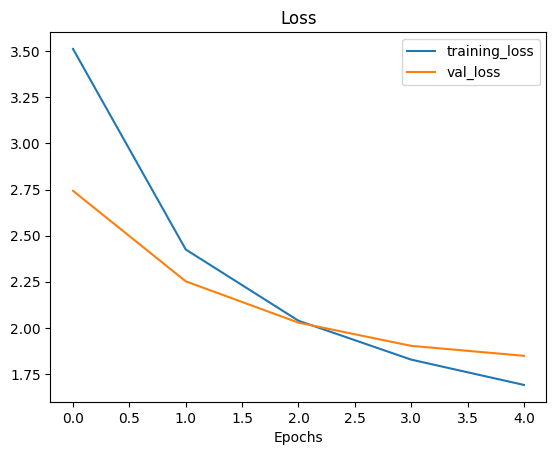

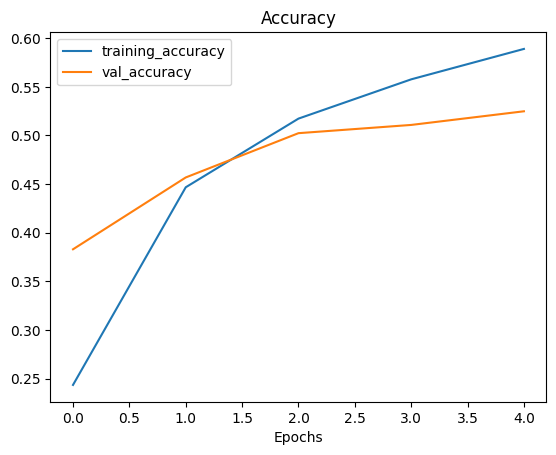

In [11]:
# Plotting loss curves
plot_loss_curves(history_all_classes_10_percent)

## Fine tuning

In [12]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

# Refreeze every layer except the last 5 
for layer in base_model.layers[:-5]:
    layer.trainable = False

In [13]:
# Recompile the model with lower learning rate 
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

In [14]:
# What layers in the model are trainable?
for layer in model.layers:
    print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetv2-b0 True
global_avg_pool_layer True
output_layer True


In [15]:
# Check which layers are trainable in our base model
for layer_number, layer in enumerate(model.layers[2].layers):
    print(layer_number, layer.name, layer.trainable)

0 input_1 False
1 rescaling False
2 normalization False
3 stem_conv False
4 stem_bn False
5 stem_activation False
6 block1a_project_conv False
7 block1a_project_bn False
8 block1a_project_activation False
9 block2a_expand_conv False
10 block2a_expand_bn False
11 block2a_expand_activation False
12 block2a_project_conv False
13 block2a_project_bn False
14 block2b_expand_conv False
15 block2b_expand_bn False
16 block2b_expand_activation False
17 block2b_project_conv False
18 block2b_project_bn False
19 block2b_drop False
20 block2b_add False
21 block3a_expand_conv False
22 block3a_expand_bn False
23 block3a_expand_activation False
24 block3a_project_conv False
25 block3a_project_bn False
26 block3b_expand_conv False
27 block3b_expand_bn False
28 block3b_expand_activation False
29 block3b_project_conv False
30 block3b_project_bn False
31 block3b_drop False
32 block3b_add False
33 block4a_expand_conv False
34 block4a_expand_bn False
35 block4a_expand_activation False
36 block4a_dwconv2 Fals

In [16]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 

# Fine-tune our model
history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)),
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1])

Epoch 5/10
237/237 [==============================] - 176s 711ms/step - loss: 1.4793 - accuracy: 0.6272 - val_loss: 1.7846 - val_accuracy: 0.5275
Epoch 6/10
237/237 [==============================] - 172s 726ms/step - loss: 1.3730 - accuracy: 0.6457 - val_loss: 1.7804 - val_accuracy: 0.5281
Epoch 7/10
237/237 [==============================] - 169s 711ms/step - loss: 1.3282 - accuracy: 0.6487 - val_loss: 1.7592 - val_accuracy: 0.5355
Epoch 8/10
237/237 [==============================] - 168s 709ms/step - loss: 1.2791 - accuracy: 0.6642 - val_loss: 1.7681 - val_accuracy: 0.5344
Epoch 9/10
237/237 [==============================] - 164s 693ms/step - loss: 1.2602 - accuracy: 0.6705 - val_loss: 1.7813 - val_accuracy: 0.5307
Epoch 10/10
237/237 [==============================] - 166s 701ms/step - loss: 1.2015 - accuracy: 0.6797 - val_loss: 1.7499 - val_accuracy: 0.5400


In [17]:
# Evaluate on the whole test data
all_classes_10_percent_fine_tune_results = model.evaluate(test_data)
all_classes_10_percent_fine_tune_results

769/790 [============================>.] - ETA: 12s - loss: 1.4789 - accuracy: 0.6046

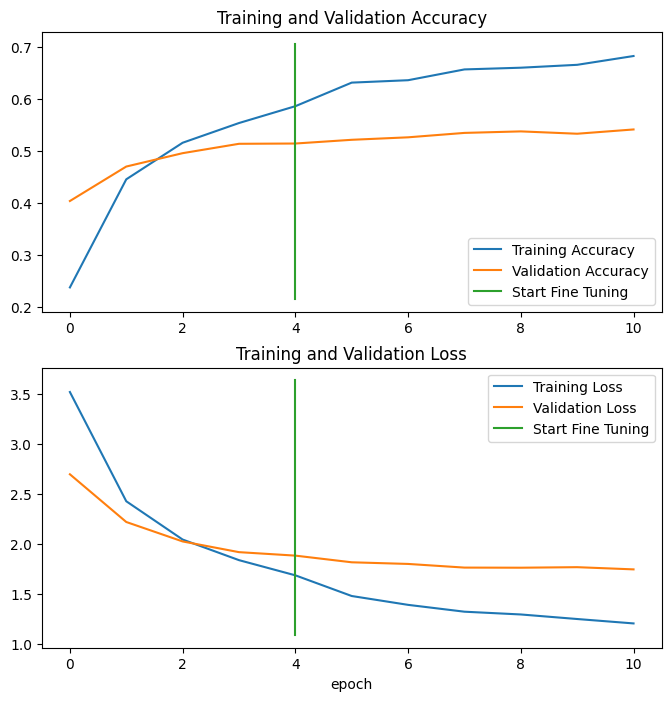

In [ ]:
# Compare the histories of feature extraction  model with fine-tuning model
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

## Saving and loading our model
To use our model in an external application, we'll need to save it and export it somewhere

In [ ]:
# Save our fine-tuning model
model.save("101_food_classes_10_percent_saved_big_dog_model")

INFO:tensorflow:Assets written to: 101_food_classes_10_percent_saved_big_dog_model\assets


INFO:tensorflow:Assets written to: 101_food_classes_10_percent_saved_big_dog_model\assets


In [7]:
# Load and evaluate saved model
loaded_model = tf.keras.models.load_model("101_food_classes_10_percent_saved_big_dog_model")

In [8]:
# Evaluate a model and compare performance to pre-saved model
loaded_model_results = loaded_model.evaluate(test_data)
loaded_model_results


790/790 [==============================] - 374s 470ms/step - loss: 1.4786 - accuracy: 0.6015


[1.4786494970321655, 0.6014653444290161]

## 

## Evaluating the performance of the big dog model across all different classes

Let's make some predictions, visualize them and then later find out which predictions were the "most" wrong.

In [9]:
import tensorflow as tf

## Making prediction with our trained model

In [10]:
# Make predictions with model
preds_probs = loaded_model.predict(test_data, verbose=1) 

790/790 [==============================] - 316s 397ms/step


In [11]:
len(preds_probs)

25250

In [12]:
# What's the shape of our predictions?
preds_probs.shape

(25250, 101)

In [13]:
# Let's se what the first 10 predicitions look like
preds_probs[:10]

array([[1.9921656e-03, 8.0172213e-05, 9.8953322e-02, ..., 2.0606401e-06,
        1.9120831e-03, 8.0593840e-05],
       [7.9012591e-01, 1.0471723e-07, 3.4990371e-03, ..., 4.9418461e-04,
        1.8312044e-06, 1.6870280e-04],
       [4.1167891e-01, 5.8008020e-04, 1.6567118e-02, ..., 1.3838350e-03,
        4.4176614e-04, 2.6029553e-03],
       ...,
       [2.1627194e-01, 2.3700013e-06, 1.6037645e-02, ..., 1.1291989e-03,
        3.5586223e-04, 7.3680014e-04],
       [6.2577687e-02, 3.0858999e-05, 1.8729173e-02, ..., 1.0070318e-03,
        2.4353810e-04, 6.6318817e-04],
       [4.7100243e-01, 2.7529214e-07, 1.8399919e-03, ..., 1.7950945e-03,
        7.8845596e-06, 3.9408533e-04]], dtype=float32)

In [14]:
# What's does the first prediction probability array look like?
preds_probs[0], len(preds_probs[0]), sum(preds_probs[0])

(array([1.9921656e-03, 8.0172213e-05, 9.8953322e-02, 7.1541166e-07,
        4.5988832e-05, 1.0695161e-04, 2.4630632e-05, 1.4339309e-05,
        3.5048259e-04, 5.5427349e-04, 1.8450426e-05, 8.4245821e-06,
        2.5325839e-04, 2.4597464e-05, 2.3746975e-02, 4.7006011e-02,
        6.6615536e-04, 8.8125421e-04, 2.5653751e-03, 6.7062565e-04,
        8.7060861e-04, 1.0188089e-05, 5.9310838e-05, 2.1532878e-05,
        8.2079554e-05, 8.9144742e-04, 3.7520817e-03, 5.1185907e-06,
        6.8913614e-03, 1.4651852e-04, 3.7308992e-06, 2.2055172e-04,
        8.2005737e-03, 2.8171746e-05, 2.4715371e-03, 3.1211726e-05,
        5.3629378e-04, 2.0641568e-03, 2.2515940e-02, 4.2382922e-04,
        5.2653719e-04, 2.7112060e-04, 4.8584916e-05, 3.1091005e-04,
        7.1777758e-05, 1.2603062e-04, 3.0469187e-04, 2.2750354e-04,
        7.1435083e-05, 1.7983381e-02, 8.9072424e-04, 3.0876722e-04,
        4.3324683e-02, 1.7191434e-02, 5.0822941e-06, 4.8601246e-04,
        2.2040950e-03, 7.8930444e-04, 2.5709469e

Our model outputs a prediction probability array (with N number of variables, where N is the number of classes) for each sample passed to the predict method.

In [15]:
# We get one prediction probability per class (in our case there's 101 prediction probabilities)
print(f"Number of prediciton probabilities for sample 0: {len(preds_probs[0])}")
print(f"What preidicition probability sample 0 looks like:\n {preds_probs[0]}")
print(f"The class with the hightest predicted probability by the model for sample 0: {preds_probs[0].argmax()}")

Number of prediciton probabilities for sample 0: 101
What preidicition probability sample 0 looks like:
 [1.9921656e-03 8.0172213e-05 9.8953322e-02 7.1541166e-07 4.5988832e-05
 1.0695161e-04 2.4630632e-05 1.4339309e-05 3.5048259e-04 5.5427349e-04
 1.8450426e-05 8.4245821e-06 2.5325839e-04 2.4597464e-05 2.3746975e-02
 4.7006011e-02 6.6615536e-04 8.8125421e-04 2.5653751e-03 6.7062565e-04
 8.7060861e-04 1.0188089e-05 5.9310838e-05 2.1532878e-05 8.2079554e-05
 8.9144742e-04 3.7520817e-03 5.1185907e-06 6.8913614e-03 1.4651852e-04
 3.7308992e-06 2.2055172e-04 8.2005737e-03 2.8171746e-05 2.4715371e-03
 3.1211726e-05 5.3629378e-04 2.0641568e-03 2.2515940e-02 4.2382922e-04
 5.2653719e-04 2.7112060e-04 4.8584916e-05 3.1091005e-04 7.1777758e-05
 1.2603062e-04 3.0469187e-04 2.2750354e-04 7.1435083e-05 1.7983381e-02
 8.9072424e-04 3.0876722e-04 4.3324683e-02 1.7191434e-02 5.0822941e-06
 4.8601246e-04 2.2040950e-03 7.8930444e-04 2.5709469e-03 4.9383634e-05
 6.7577997e-07 3.0672923e-03 2.2686666e-03 

In [16]:
test_data.class_names[85]

'samosa'

In [17]:
# Get the pred classes of each label
pred_classes = preds_probs.argmax(axis=1)

# How do they look?
pred_classes[:10]

array([85,  0,  0,  0,  8, 78, 29, 46,  9,  0], dtype=int64)

Now we've got a predictions arrary of all of our model's predictions, to evaluate them, we need to compare them to the truth labels. 

In [18]:
# To get our test labels we need to unravel our test_data BatchDataset
y_labels = []
for images, labels in test_data.unbatch():
    y_labels.append(labels.numpy().argmax()) # Currently test labels look like: [0, 0, 0, 1, ... , 0, 0], we want the index value when 1 occurs
y_labels[:10] # look at the first 10

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [19]:
# How many y_labels are there?
len(y_labels)

25250

## Evaluating our model's predictions

In [20]:
# Let's try scikit-learn's accuracy score function and see what it comes up with
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_true=y_labels,
                                  y_pred=pred_classes)
sklearn_accuracy

0.6014653465346534

In [21]:
# Does this metric come close to our model's 
import numpy as np
np.isclose(loaded_model_results[1], sklearn_accuracy)

True

## Let's get visual: making a confusion matrix

In [22]:
from helper_functions import make_confusion_matrix

In [23]:
# Get a list of class names
class_names = test_data.class_names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [26]:
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      savefig=True)

In [25]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Our function needs a different name to sklearn's plot_confusion_matrix
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False): 
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).
  
  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """  
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])
  
  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes), 
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)
  
  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()
  
  ## Changed (plot x-labels vertically)
  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)
  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")

## Let's keep the evaluation train going, time for a classification report

Scikit-learn has a helpful function for acquiring many different classification metrics per class (e.g. precision, recall and F1) called classification repot.

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_true=y_labels,
                            y_pred=pred_classes))

              precision    recall  f1-score   support

           0       0.41      0.20      0.27       250
           1       0.63      0.66      0.64       250
           2       0.76      0.43      0.55       250
           3       0.70      0.55      0.62       250
           4       0.48      0.42      0.45       250
           5       0.62      0.33      0.43       250
           6       0.77      0.78      0.78       250
           7       0.83      0.70      0.76       250
           8       0.32      0.49      0.39       250
           9       0.33      0.78      0.46       250
          10       0.59      0.40      0.47       250
          11       0.70      0.56      0.62       250
          12       0.62      0.67      0.64       250
          13       0.59      0.56      0.57       250
          14       0.41      0.63      0.49       250
          15       0.33      0.37      0.35       250
          16       0.70      0.48      0.57       250
          17       0.41    

### Creating visualization of classification report for better understanding

In [28]:
# Get a dictionary of the classification report
classification_report_dict = classification_report(y_labels, pred_classes, output_dict=True)
classification_report_dict

{'0': {'precision': 0.4065040650406504,
  'recall': 0.2,
  'f1-score': 0.2680965147453083,
  'support': 250.0},
 '1': {'precision': 0.6273764258555133,
  'recall': 0.66,
  'f1-score': 0.6432748538011696,
  'support': 250.0},
 '2': {'precision': 0.7588652482269503,
  'recall': 0.428,
  'f1-score': 0.5473145780051151,
  'support': 250.0},
 '3': {'precision': 0.700507614213198,
  'recall': 0.552,
  'f1-score': 0.6174496644295302,
  'support': 250.0},
 '4': {'precision': 0.4751131221719457,
  'recall': 0.42,
  'f1-score': 0.4458598726114649,
  'support': 250.0},
 '5': {'precision': 0.6240601503759399,
  'recall': 0.332,
  'f1-score': 0.4334203655352481,
  'support': 250.0},
 '6': {'precision': 0.7707509881422925,
  'recall': 0.78,
  'f1-score': 0.7753479125248508,
  'support': 250.0},
 '7': {'precision': 0.8325358851674641,
  'recall': 0.696,
  'f1-score': 0.7581699346405228,
  'support': 250.0},
 '8': {'precision': 0.32114882506527415,
  'recall': 0.492,
  'f1-score': 0.3886255924170616,


In [29]:
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [30]:
# Let's plot all of our classes F1-scores

# Create empty dictionary
class_f1_scores = {}

# Loop through classification report dictionary items
for k, v in classification_report_dict.items():
    if k == "accuracy": # stop once we get to accuracy key
        break
    else:
        # Add class names and f1-scores to new dictionary
        class_f1_scores[class_names[int(k)]] = v["f1-score"]
        
class_f1_scores

{'apple_pie': 0.2680965147453083,
 'baby_back_ribs': 0.6432748538011696,
 'baklava': 0.5473145780051151,
 'beef_carpaccio': 0.6174496644295302,
 'beef_tartare': 0.4458598726114649,
 'beet_salad': 0.4334203655352481,
 'beignets': 0.7753479125248508,
 'bibimbap': 0.7581699346405228,
 'bread_pudding': 0.3886255924170616,
 'breakfast_burrito': 0.4630071599045345,
 'bruschetta': 0.4736842105263158,
 'caesar_salad': 0.6208425720620844,
 'cannoli': 0.6423076923076924,
 'caprese_salad': 0.5731958762886599,
 'carrot_cake': 0.49375,
 'ceviche': 0.3465160075329567,
 'cheese_plate': 0.5721040189125296,
 'cheesecake': 0.4312977099236641,
 'chicken_curry': 0.47317073170731705,
 'chicken_quesadilla': 0.5417607223476297,
 'chicken_wings': 0.7041666666666666,
 'chocolate_cake': 0.5443298969072166,
 'chocolate_mousse': 0.41454545454545455,
 'churros': 0.734966592427617,
 'clam_chowder': 0.7535641547861506,
 'club_sandwich': 0.6353944562899787,
 'crab_cakes': 0.3915343915343915,
 'creme_brulee': 0.704288

In [31]:
# Turn f1-scores into dataframe for visualization
import pandas as pd

f1_scores = pd.DataFrame({"class_names": list(class_f1_scores.keys()),
                          "f1-score": list(class_f1_scores.values())}).sort_values("f1-score", ascending=False)

In [33]:
f1_scores.head()

,class_names,f1-score
33,edamame,0.962672
75,pho,0.865306
63,macarons,0.864745
69,oysters,0.848980
65,mussels,0.846626
